In [1]:
import os

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from astropy.coordinates import SkyCoord
from astropy.io import fits
from gammapy.irf import load_irf_dict_from_file
from scipy.stats import chi2, poisson
from scipy.optimize import curve_fit

**Adjust with the correct file paths**

In [2]:
name = "Mrk501"
blazar_coord = SkyCoord.from_name(name)
data_folder = "../cta_dc_data/mrk_501/"
irf_file = "../cta_dc_data/irfs/Prod5-North-40deg-AverageAz-4LSTs09MSTs.180000s-v0.1.fits.gz"

In [3]:
blazar_l = blazar_coord.galactic.l.deg
blazar_b = blazar_coord.galactic.b.deg

hbus = []
for filename in os.listdir(data_folder):
    hbus.append(fits.open(data_folder + filename))

irf = load_irf_dict_from_file(irf_file)
aeff = irf["aeff"]
print(f"Pointings: {len(hbus)}")

Pointings: 126


In [4]:
e_bins=np.logspace(np.log10(0.05), np.log10(50), 16)
e_mins=e_bins[:-1]
e_maxs=e_bins[1:]
e=np.sqrt(e_mins*e_maxs)
de=e_maxs-e_mins

th2_bins=np.linspace(0,0.16,17)
th2=(th2_bins[1:]+th2_bins[:-1])/2.

**Data collecting and overview**

In [5]:
bkg_subtraction_radius = 0.4

cts_s = np.zeros((len(e), len(th2)))
cts_b = np.zeros((len(e), len(th2)))

t_expo = 0

for hbu in hbus:
    data_raw = hbu["EVENTS"].data

    t = data_raw["TIME"]
    t = np.sort(t)
    t_expo += t[-1] - t[0]

    coord = SkyCoord(
        ra=data_raw["RA"] * u.deg, dec=data_raw["DEC"] * u.deg, frame="icrs"
    )

    pointing_coord = SkyCoord(
        ra=hbu[1].header["RA_PNT"] * u.deg,
        dec=hbu[1].header["DEC_PNT"] * u.deg,
        frame="icrs",
    )

    bkg_center = SkyCoord(
        l=2 * pointing_coord.galactic.l - blazar_coord.galactic.l,
        b=2 * pointing_coord.galactic.b - blazar_coord.galactic.b,
        frame="galactic",
    )
    
    seps = coord.separation(blazar_coord).degree
    seps_b = coord.separation(bkg_center).degree
    src_pos_mask = seps < bkg_subtraction_radius
    bkg_pos_mask = seps_b < bkg_subtraction_radius

    energ = data_raw["ENERGY"]

    for i, (energ_min, energ_max) in enumerate(zip(e_mins, e_maxs)):
        m_s = (energ>energ_min) & (energ<energ_max) & src_pos_mask
        m_b = (energ>energ_min) & (energ<energ_max )& bkg_pos_mask

        h_s, _ = np.histogram(seps[m_s]**2, bins=th2_bins)
        h_b, _ = np.histogram(seps_b[m_b]**2, bins=th2_bins)
        
        cts_s[i] += h_s
        cts_b[i] += h_b

print(f"Exposure time = {t_expo/60/60:.1f}h")

Exposure time = 17.8h


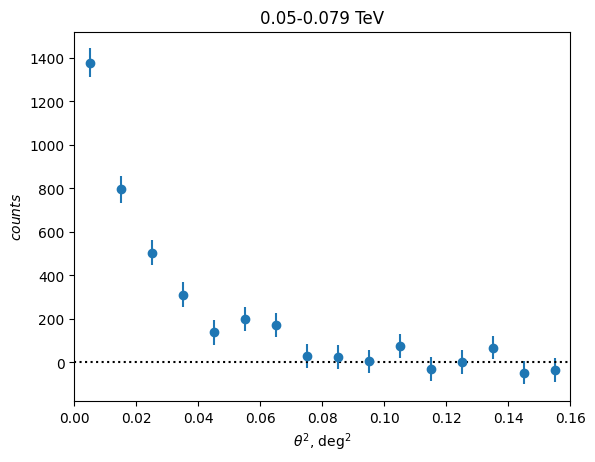

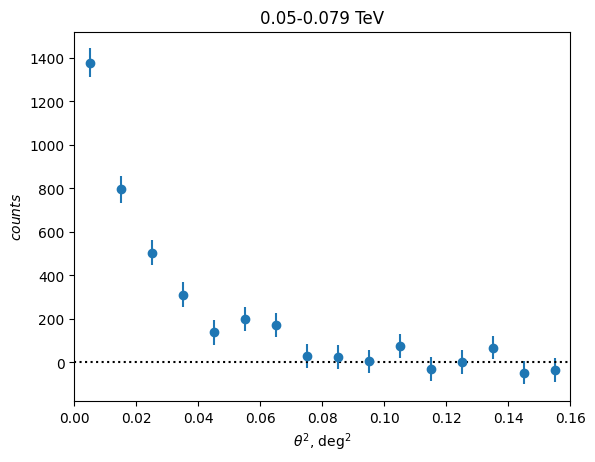

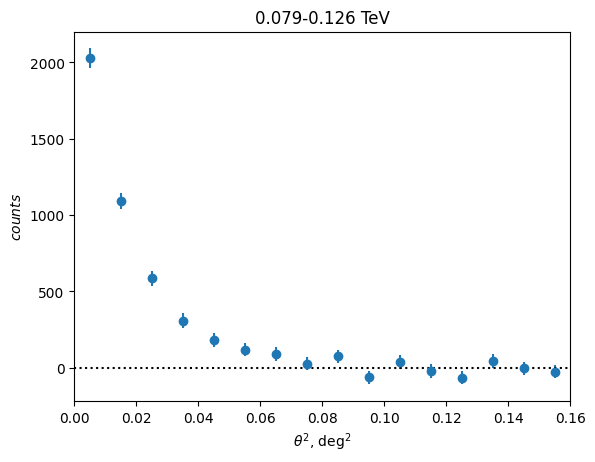

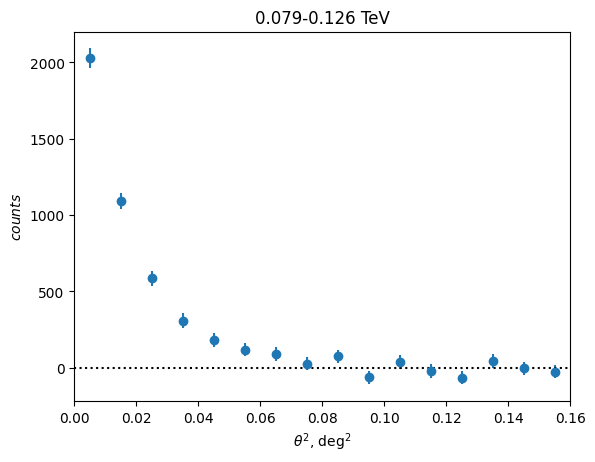

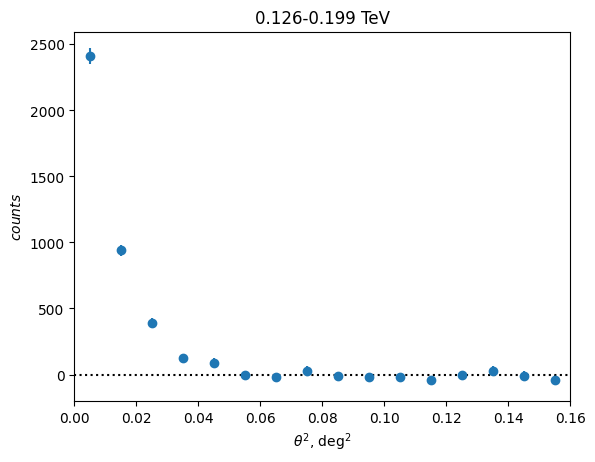

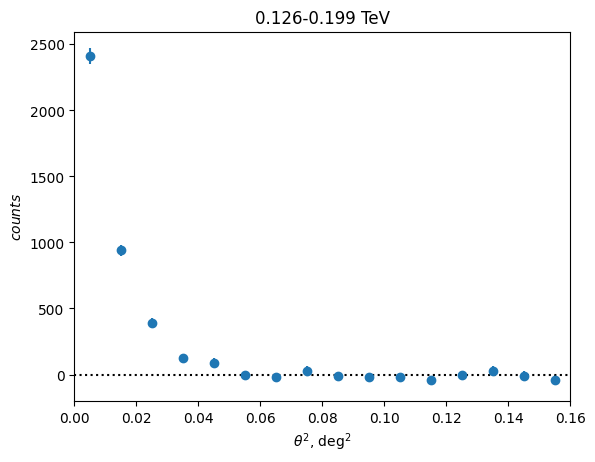

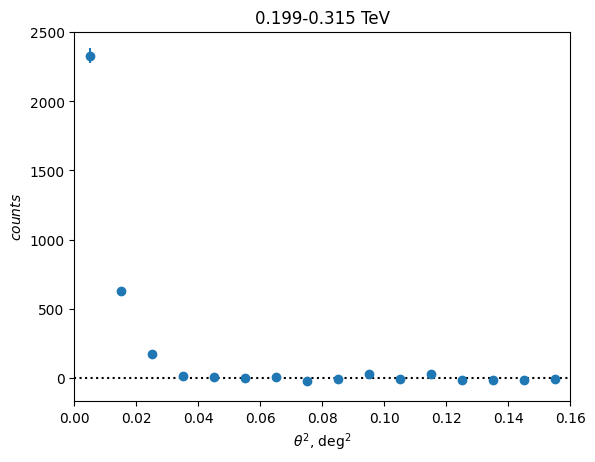

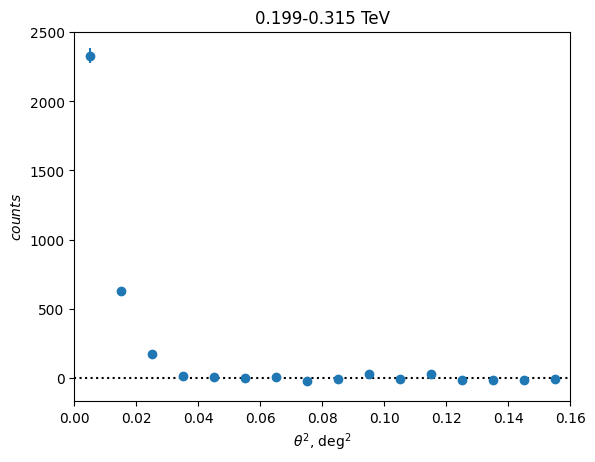

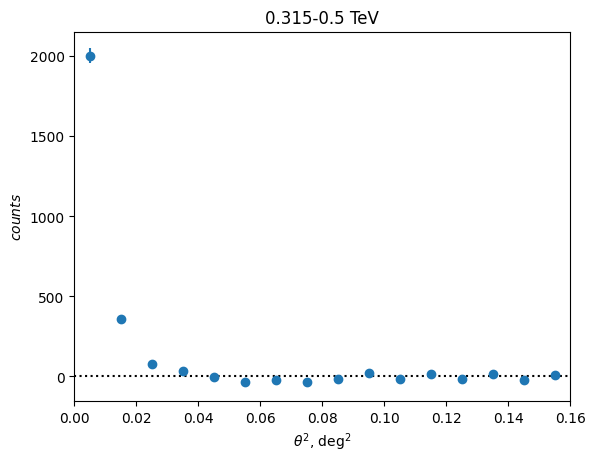

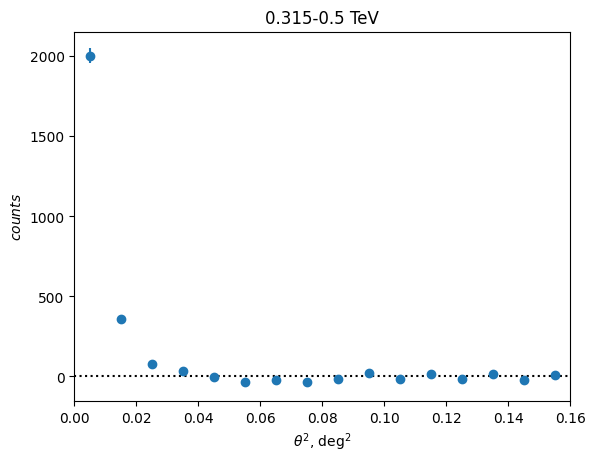

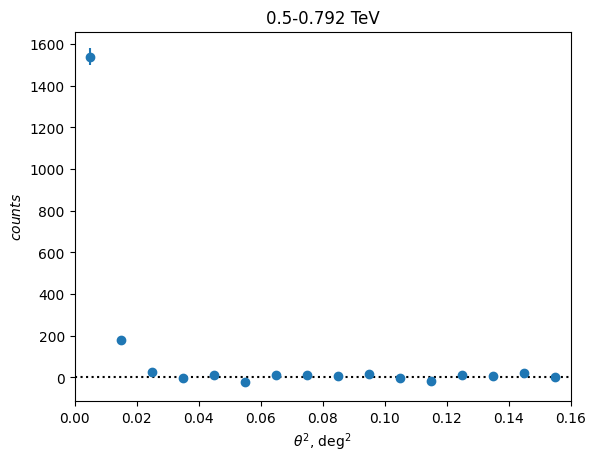

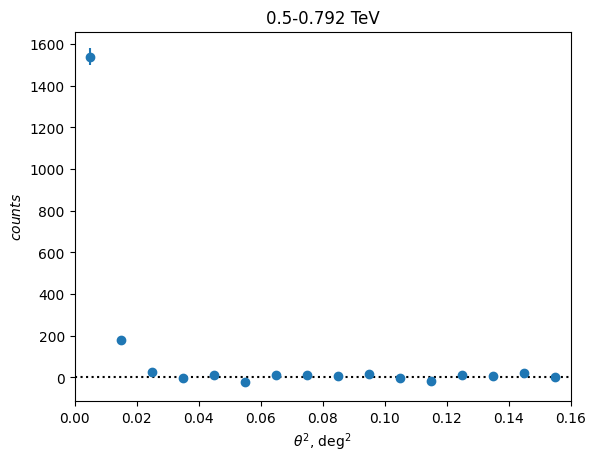

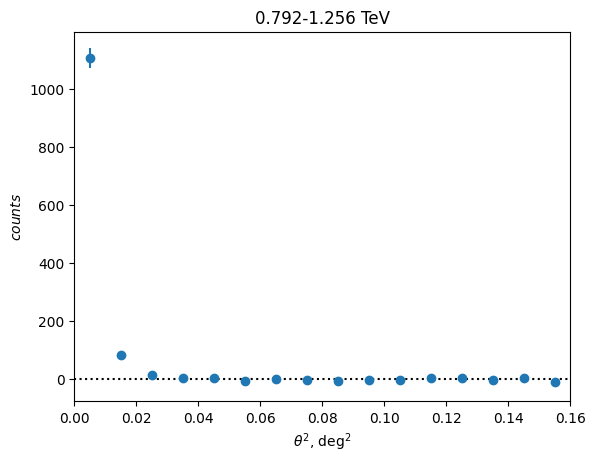

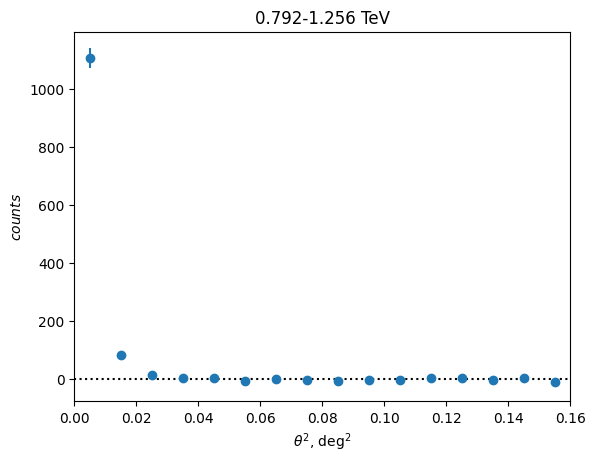

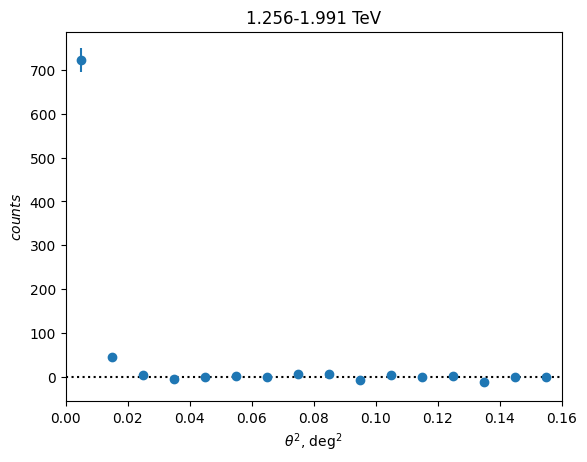

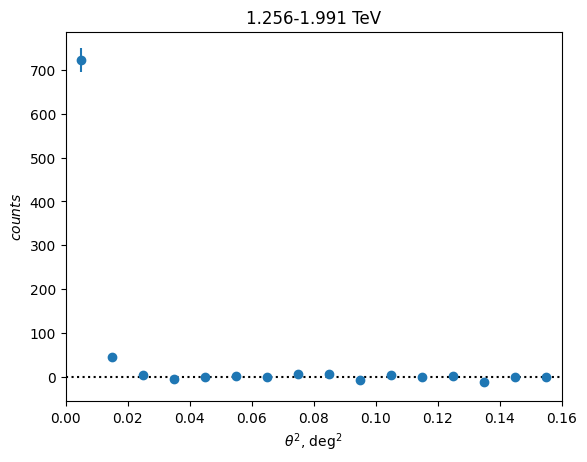

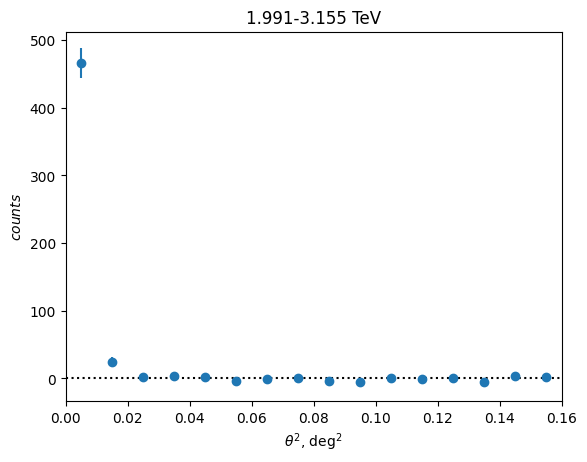

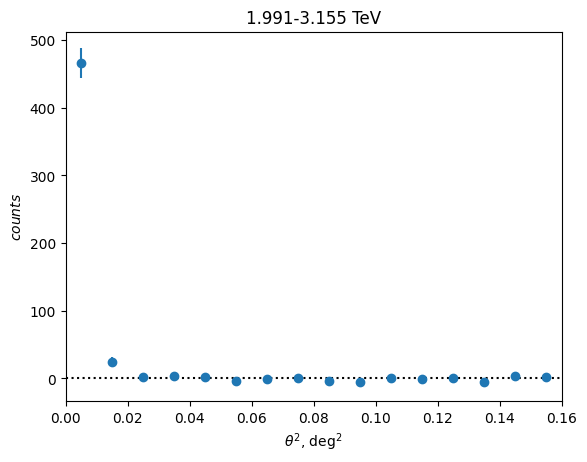

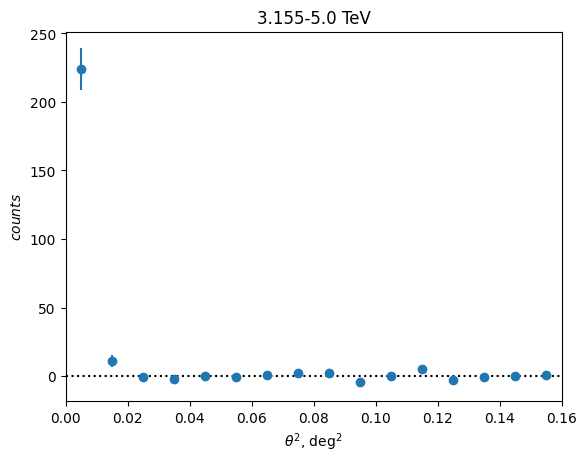

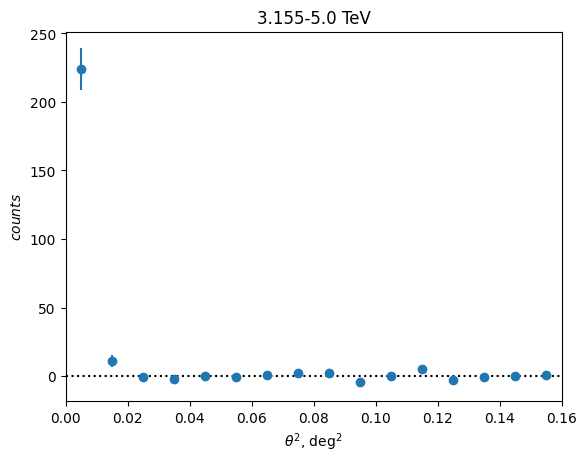

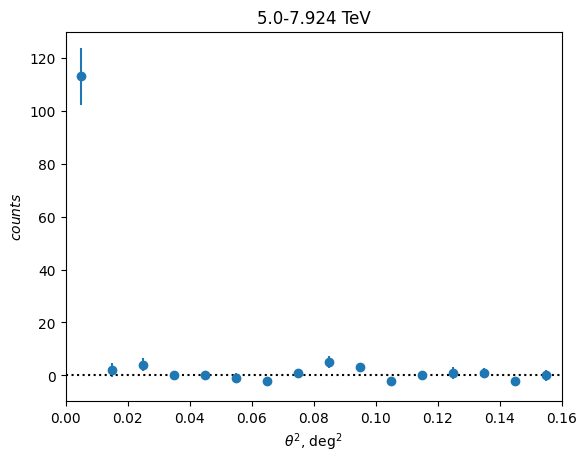

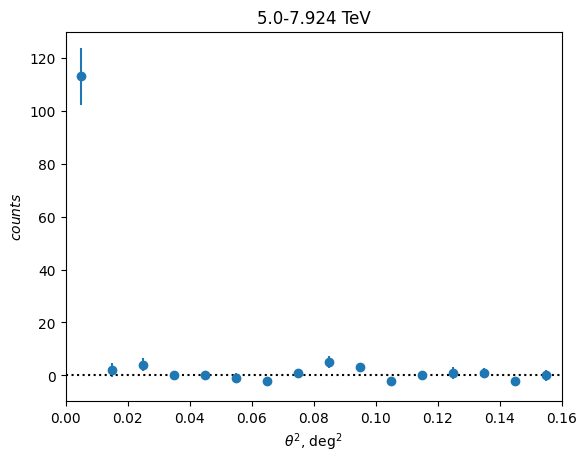

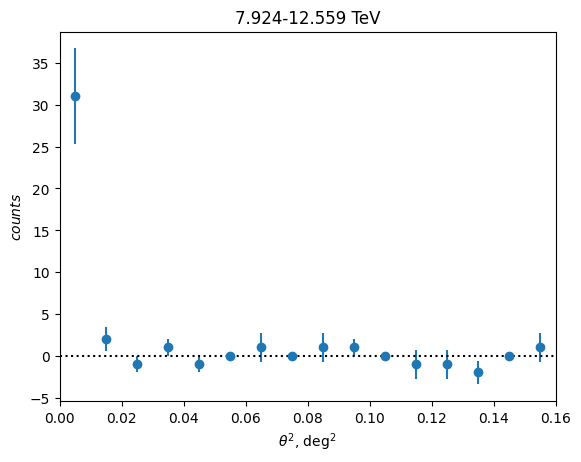

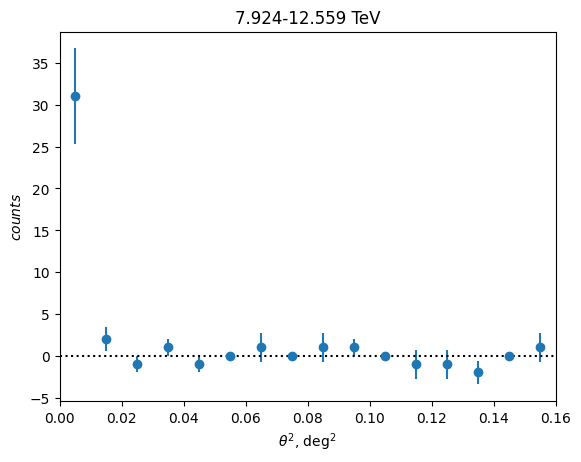

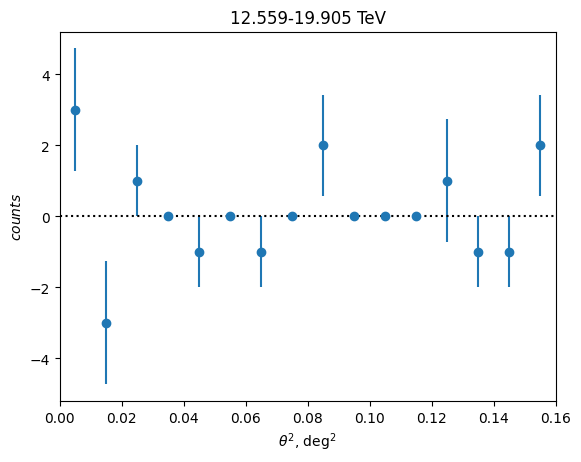

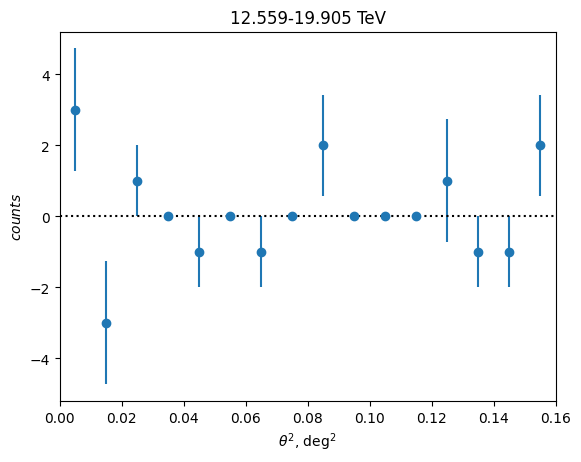

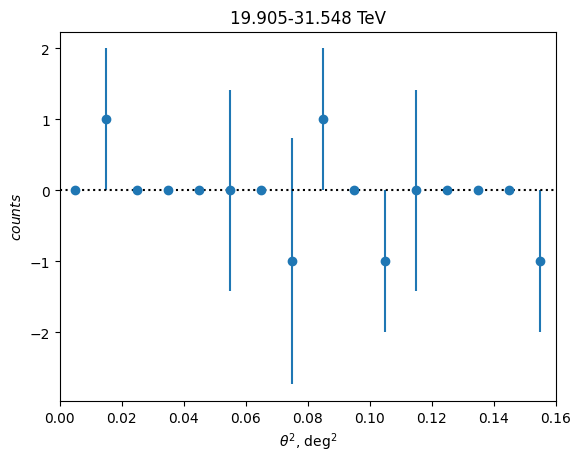

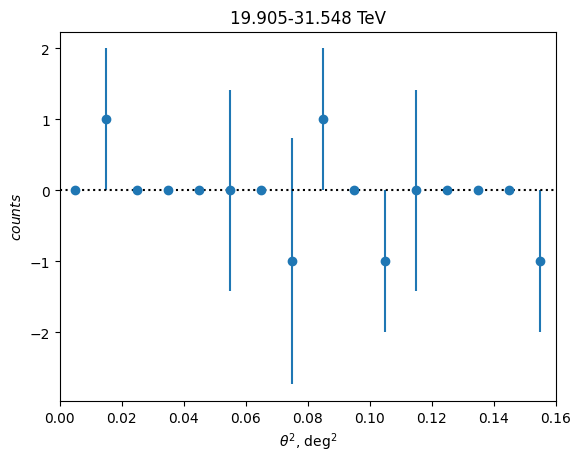

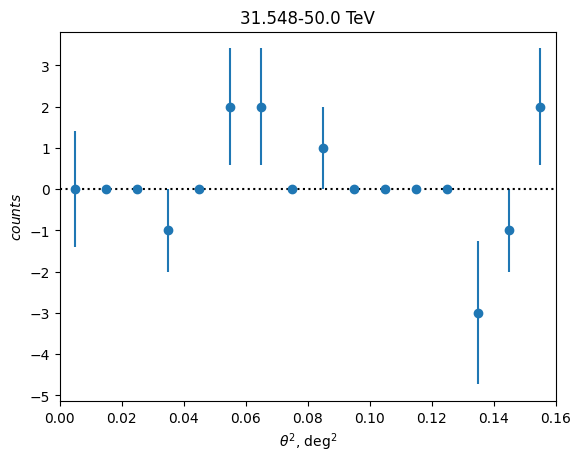

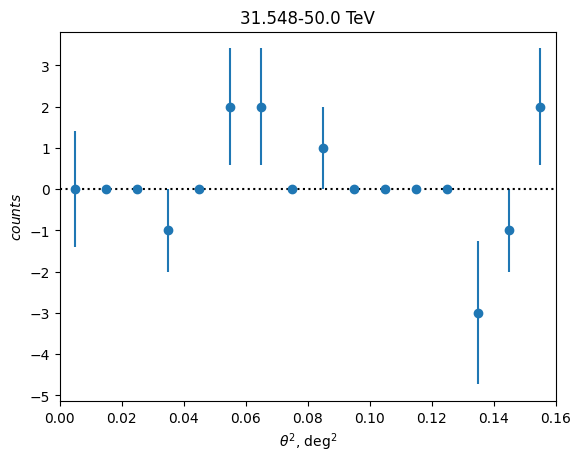

In [6]:
cts = cts_s - cts_b
cts_err = np.sqrt(cts_s + cts_b)


for i in range(cts.shape[0]):
    plt.figure()
    plt.errorbar(th2,cts[i], cts_err[i],fmt='o')
    plt.axhline(0,color='black',linestyle='dotted')
    plt.xlim(0,0.16)
    plt.title(str(round(e_mins[i],3))+'-'+str(round(e_maxs[i],3))+' TeV')
    plt.xlabel(r'$\theta^2$, deg$^2$')
    plt.ylabel(r'$counts$')
    plt.show()

    plt.figure()
    plt.errorbar(th2,cts[i], cts_err[i],fmt='o')
    plt.axhline(0,color='black',linestyle='dotted')
    plt.xlim(0,0.16)
    plt.title(str(round(e_mins[i],3))+'-'+str(round(e_maxs[i],3))+' TeV')
    plt.xlabel(r'$\theta^2$, deg$^2$')
    plt.ylabel(r'$counts$')
    plt.show()

In [7]:
psf_hbu = irf["psf"]
print(psf_hbu)
print(psf_hbu.info())
print(psf_hbu.data.shape)
# here i'm guessing the energy bins of the psf since idk how to see them.
psf_e_bins = np.logspace(np.log10(0.013), np.log10(199.526), 22)
print(psf_e_bins)

EnergyDependentMultiGaussPSF
----------------------------

  axes      : ['energy_true', 'offset']
  shape     : (21, 6)
  ndim      : 2
  parameters: ['sigma_1', 'sigma_2', 'sigma_3', 'scale', 'ampl_2', 'ampl_3']


Summary PSF info
----------------
Theta          : size =     6, min =  0.500 deg, max =  5.500 deg
Energy hi      : size =    21, min =  0.020 TeV, max = 199.526 TeV
Energy lo      : size =    21, min =  0.013 TeV, max = 125.893 TeV
68.00 containment radius at offset = 0.0 deg and energy_true =  1.0 TeV: 0.074 deg
95.00 containment radius at offset = 0.0 deg and energy_true =  1.0 TeV: 0.121 deg
68.00 containment radius at offset = 0.0 deg and energy_true = 10.0 TeV: 0.062 deg
95.00 containment radius at offset = 0.0 deg and energy_true = 10.0 TeV: 0.100 deg

(21, 6)
[1.30000000e-02 2.05721347e-02 3.25548251e-02 5.15170959e-02
 8.15243565e-02 1.29010003e-01 2.04154705e-01 3.23069084e-01
 5.11247747e-01 8.09035193e-01 1.28027546e+00 2.02599994e+00
 3.20608797e+00 5.07354412

converged at 
738
2.725754847514854
converged at 
690
2.7511063436319807
converged at 
661
2.7182006763678954
converged at 
647
2.752852183076514


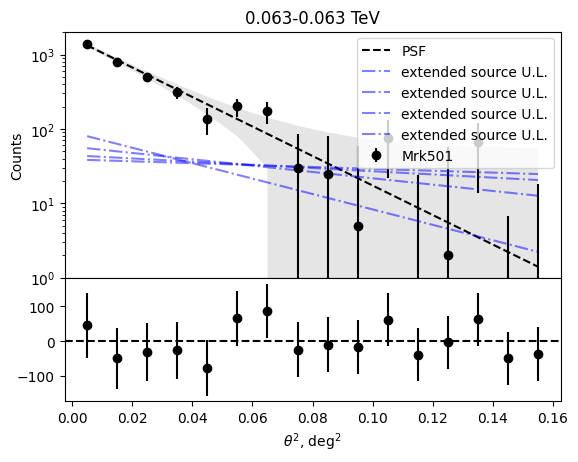

converged at 
765
2.7443746882506206
converged at 
709
2.7461972152419962
converged at 
672
2.7699543848588393
converged at 
653
2.76942101218716


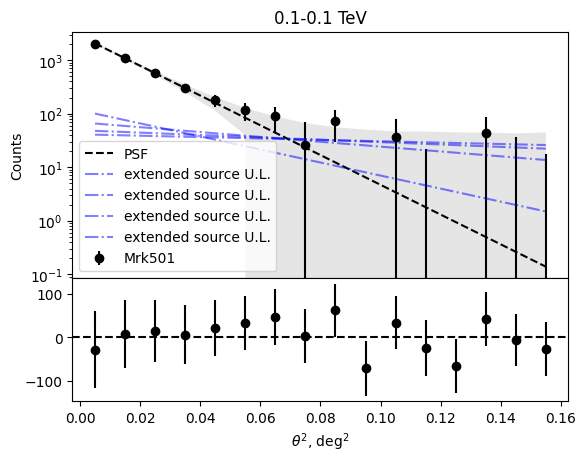

converged at 
680
2.720194122689577
converged at 
583
2.7387721188154988
converged at 
544
2.739789951600379
converged at 
526
2.714236203488653


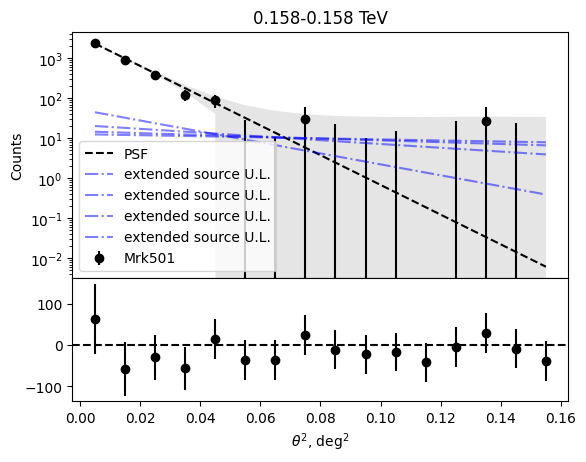

converged at 
624
2.7137306548184092
converged at 
540
2.7378158818556297
converged at 
510
2.72519093184774
converged at 
497
2.73327810639066


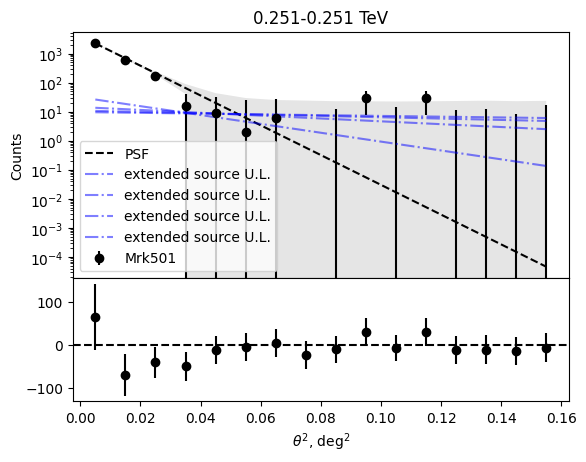

converged at 
586
2.7136792934638265
converged at 
479
2.730707535895821
converged at 
444
2.724691513889997
converged at 
430
2.7347339274963467


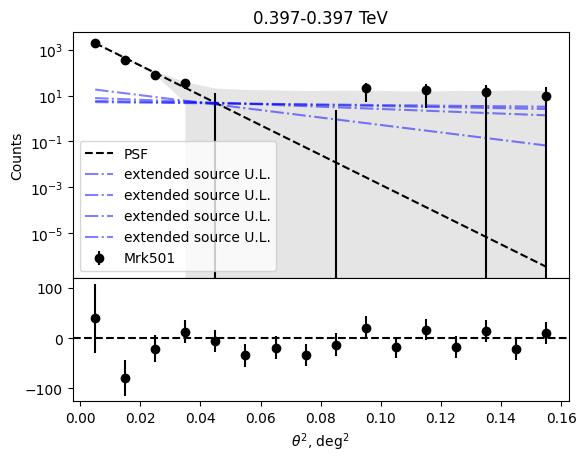

converged at 
526
2.724871682530786
converged at 
477
2.741950377500512
converged at 
468
2.7484813871047216
converged at 
463
2.7541917454577742


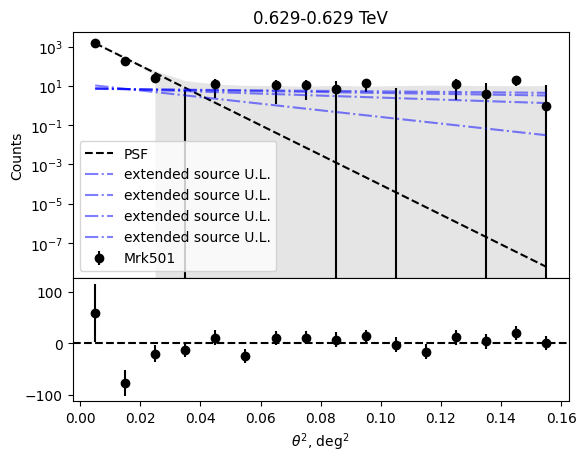

converged at 
506
2.7244421692746794
converged at 
414
2.7179865545415165
converged at 
379
2.733256422704274
converged at 
363
2.729477998607118


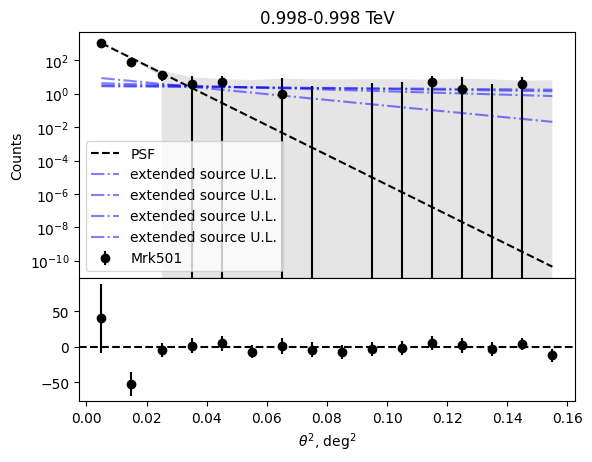

converged at 
460
2.7166340465239927
converged at 
376
2.718210515770881
converged at 
341
2.7301858521926086
converged at 
324
2.7135356419577903


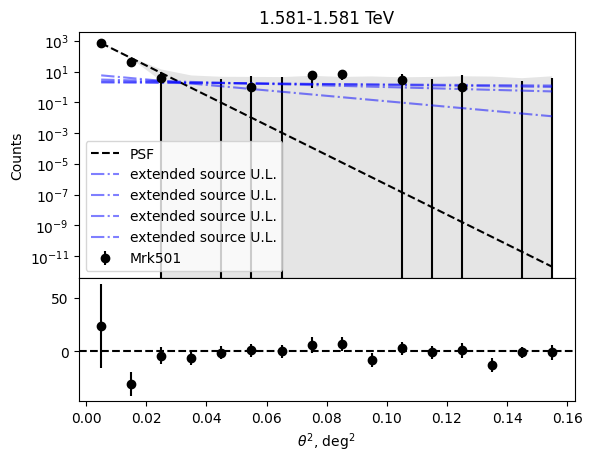

converged at 
467
2.7205337431373984
converged at 
362
2.7390166737552377
converged at 
325
2.7174694632698007
converged at 
310
2.728403938639614


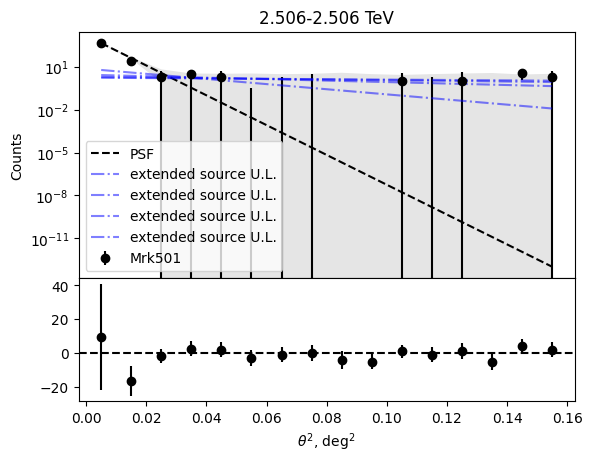

converged at 
405
2.7144613036555114
converged at 
296
2.7270242137069616
converged at 
260
2.7433690934583623
converged at 
244
2.724934034598361


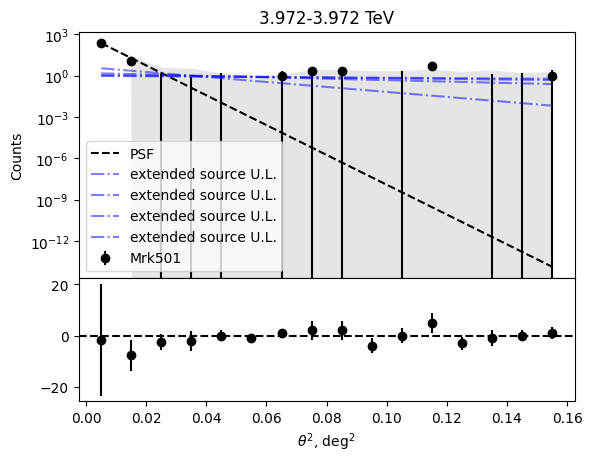

converged at 
429
2.7127708138340374
converged at 
331
2.715860210861571
converged at 
291
2.7229084109861947
converged at 
273
2.725906591120797


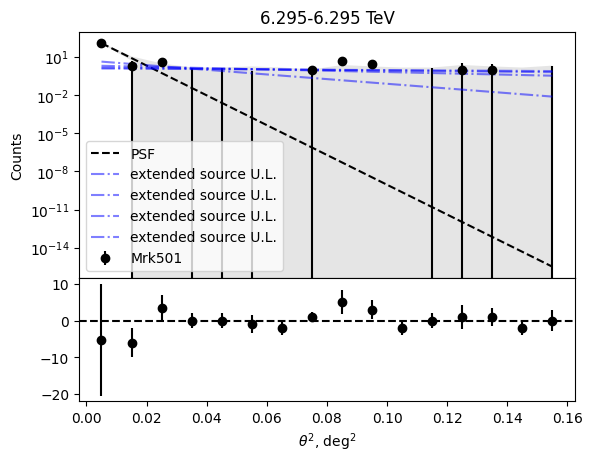

/tmp/ipykernel_1939/4082156189.py:28: RuntimeWarning: divide by zero encountered in divide
  chi2_noext = np.sum(((ct - psf_component)**2 / (ct_err**2 + psf_component_err**2)))
/tmp/ipykernel_1939/4082156189.py:80: RuntimeWarning: divide by zero encountered in divide
  chi2_ext = np.sum(((ct - ct_ext_plus_src)**2 / (ct_err**2 + psf_component_err**2)))
/tmp/ipykernel_1939/4082156189.py:82: RuntimeWarning: invalid value encountered in scalar subtract
  delta_chi2 = chi2_ext - chi2_noext


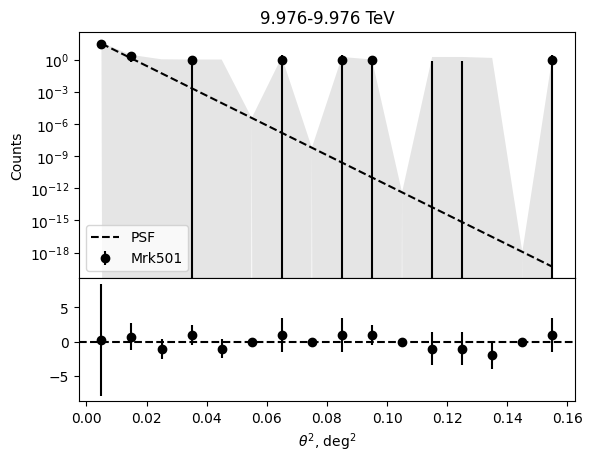

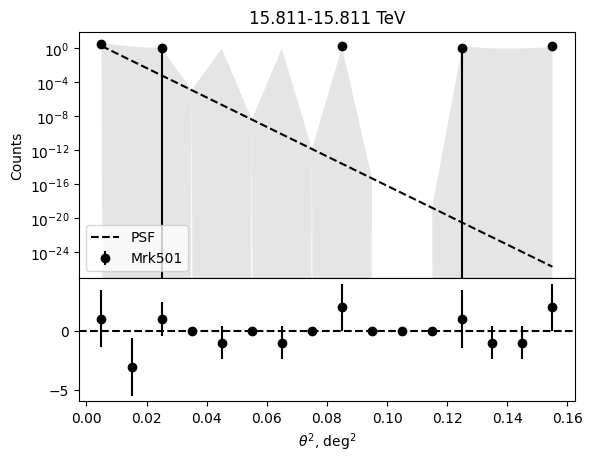

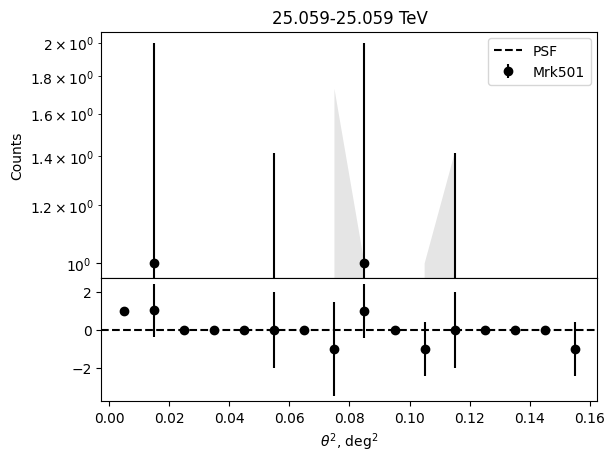

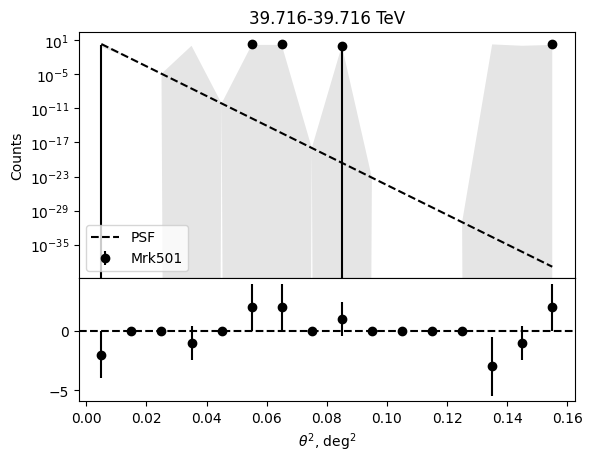

In [10]:
sigmas_ext = [0.1, 0.2, 0.3, 0.4]
norms_ext = np.logspace(np.log10(0.1), np.log10(1000), 1000)

flux_ratios = np.zeros((len(sigmas_ext), len(e)))

for i, (ct, ct_err) in enumerate(zip(cts, cts_err)):
    # psf_index will store the best index for accessing the PSF values form the file.
    psf_index = None
    for j in range(len(psf_e_bins) - 1):
        if psf_e_bins[j] <= e[i] < psf_e_bins[j+1]:
            psf_index = j
            break
    sigma_1, sigma_2, sigma_3, scale, ampl_2, ampl_3 = psf_hbu.data[psf_index][0]

    # Normalization of the PSF model to fit best the blazar
    def psf_model(th2):
        gauss1 = np.exp(-th2 / (2 * sigma_1**2))
        gauss2 = ampl_2*np.exp(-th2 / (2 * sigma_2**2))
        gauss3 = ampl_3*np.exp(-th2 / (2 * sigma_3**2))
        return (gauss1+gauss2+gauss3)

    psf_component = psf_model(th2)
    # rescaling the error
    psf_component_err = ct_err*sum(psf_component)/sum(ct)
    # rescaling the psf component to match total counts of the data
    psf_component_err *= sum(ct)/sum(psf_component)
    psf_component *= sum(ct)/sum(psf_component)
    chi2_noext = np.sum(((ct - psf_component)**2 / (ct_err**2 + psf_component_err**2)))

    # taken from andrii notebook, to fit with psf better:
    step=1.01
    chi2_noext_best=1e10
    adjust=1
    while(chi2_noext<chi2_noext_best):
        chi2_noext_best=chi2_noext
        chisq0=sum((ct-step*adjust*psf_component)**2/(ct_err**2+(adjust*step*psf_component_err)**2))
        chisq1=sum((ct-adjust*psf_component/step)**2/(ct_err**2+(adjust*psf_component_err/step)**2))
        chisq_vec=np.array([chisq0,chisq1])
        chi2_noext=min(chisq_vec)
        ind=np.argmin(chisq_vec)
        if(chi2_noext<chi2_noext_best):
            if(ind==0):
                adjust*=step
            if(ind==1):
                adjust/=step
    psf_component=adjust*psf_component
    psf_component_err=adjust*psf_component_err
    
    fig, axs = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [2, 1]})
    fig.subplots_adjust(hspace=0)
    axs[0].errorbar(th2,ct,ct_err,linestyle='none',marker='o',label=name,color='black')
    axs[0].plot(th2,psf_component,color='black',linestyle='dashed',label='PSF')
    axs[0].fill_between(th2,(psf_component-psf_component_err),(psf_component+psf_component_err),color='black',alpha=0.1,linewidth=0)
    axs[0].set_title(str(round(e[i],3))+'-'+str(round(e[i],3))+r' TeV')
    axs[1].errorbar(th2,ct - psf_component,np.sqrt(ct_err**2+psf_component_err**2),marker='o',linestyle='none',color='black')
    axs[1].axhline(0,color='black',linestyle='dashed')

    # For each sigma_ext: add a gaussian term norm_ext*gauss(sigma_ext) convolved with the psf, to the point source model (psf only), until delta_chi2 is > 2.71.
    # With this you found norm_ext such that the fit breaks. Lets call this norm_ext_br
    # Then the upper limit to the detectable ext. emission should be given by an extended emission of the form of: norm_ext_br*gauss(sigma_ext).
    for k, sigma_ext in enumerate(sigmas_ext):
        found_value = False
        for j, norm_ext in enumerate(norms_ext):
            if found_value:
                continue
            def ext_model(th2):
                sigma1_conv = np.sqrt(sigma_1**2 + sigma_ext**2)
                sigma2_conv = np.sqrt(sigma_2**2 + sigma_ext**2)
                sigma3_conv = np.sqrt(sigma_3**2 + sigma_ext**2)
                gauss1_conv = np.exp(-th2 / (2 * sigma1_conv**2))
                gauss2_conv = ampl_2 * np.exp(-th2 / (2 * sigma2_conv**2))
                gauss3_conv = ampl_3 * np.exp(-th2 / (2 * sigma3_conv**2))
                return norm_ext * (gauss1_conv + gauss2_conv + gauss3_conv)
        
            ct_ext = ext_model(th2)
            # here i renormalize the point source taking away te extended emission counts. (...NOT)
            #no_ext_renormaliz = 1 - np.sum(ct_ext)/np.sum(psf_component)
            #ct_ext_plus_src = ct_ext+psf_component*no_ext_renormaliz
            ct_ext_plus_src = ct_ext+psf_component
            chi2_ext = np.sum(((ct - ct_ext_plus_src)**2 / (ct_err**2 + psf_component_err**2)))
                              
            delta_chi2 = chi2_ext - chi2_noext
            if delta_chi2 > 2.71:
                flux_ratio = np.sum(ct_ext)/(np.sum(psf_component) + np.sum(ct_ext))
                flux_ratios[k][i] = flux_ratio
                found_value = True
                print("converged at ")
                print(j)
                print(delta_chi2)

                axs[0].plot(th2,ct_ext,color='blue',alpha=0.5,linestyle='dashdot',label='extended source U.L.')
    plt.xlabel(r'$\theta^2$, deg$^2$')
    axs[0].set_ylabel('Counts')
    axs[0].legend()
    axs[0].set_yscale('log')
    plt.show()

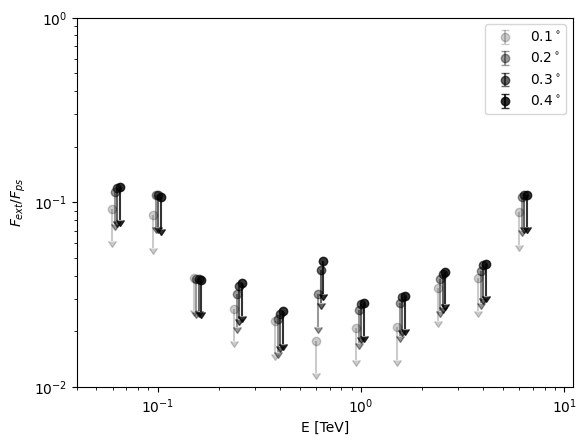

In [18]:
for i, flux_ratio in enumerate(flux_ratios):
    plt.errorbar(e*(0.95*1.03**i), flux_ratio,flux_ratio/3, alpha=0.2+0.2*i, uplims=True, linestyle='none',marker='o', label=str(round(sigmas_ext[i],3))+r'$^\circ$',color='black')
plt.xscale("log")
plt.yscale("log")
plt.ylabel(r"$F_{ext}/F_{ps}$")
plt.xlabel("E [TeV]")
plt.xlim(0.04,11)
plt.ylim(0.01,1)
plt.legend()

Here i do the same algorithm as andrii to se if its any different

NameError: name 'cts_point' is not defined

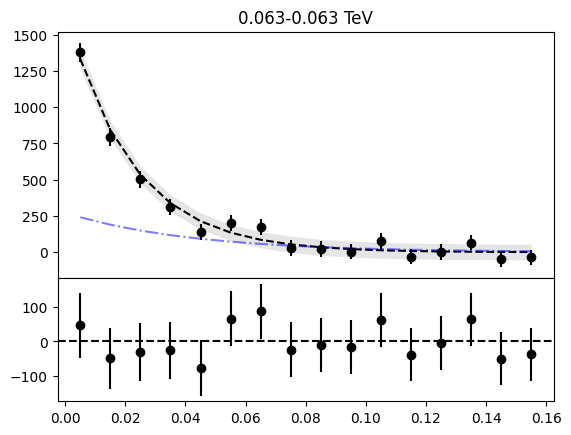

In [12]:
sigmas_ext = [0.1, 0.2, 0.3, 0.4]
flux_ratios = np.zeros((len(sigmas_ext), len(e)))
chi2max = 2.71

for i, (ct, ct_err) in enumerate(zip(cts, cts_err)):
    # psf_index will store the best index for accessing the PSF values form the file.
    psf_index = None
    for j in range(len(psf_e_bins) - 1):
        if psf_e_bins[j] <= e[i] < psf_e_bins[j+1]:
            psf_index = j
            break
    sigma_1, sigma_2, sigma_3, scale, ampl_2, ampl_3 = psf_hbu.data[psf_index][0]

    # Normalization of the PSF model to fit best the blazar
    def psf_model(th2):
        gauss1 = np.exp(-th2 / (2 * sigma_1**2))
        gauss2 = ampl_2*np.exp(-th2 / (2 * sigma_2**2))
        gauss3 = ampl_3*np.exp(-th2 / (2 * sigma_3**2))
        return (gauss1+gauss2+gauss3)

    psf_component = psf_model(th2)
    # rescaling the error
    psf_component_err = ct_err*sum(psf_component)/sum(ct)
    # rescaling the psf component to match total counts of the data
    psf_component_err *= sum(ct)/sum(psf_component)
    psf_component *= sum(ct)/sum(psf_component)
    chi2_noext = np.sum(((ct - psf_component)**2 / (ct_err**2 + psf_component_err**2)))

    # taken from andrii notebook, to fit with psf better:
    step=1.01
    chi2_noext_best=1e10
    adjust=1
    while(chi2_noext<chi2_noext_best):
        chi2_noext_best=chi2_noext
        chisq0=sum((ct-step*adjust*psf_component)**2/(ct_err**2+(adjust*step*psf_component_err)**2))
        chisq1=sum((ct-adjust*psf_component/step)**2/(ct_err**2+(adjust*psf_component_err/step)**2))
        chisq_vec=np.array([chisq0,chisq1])
        chi2_noext=min(chisq_vec)
        ind=np.argmin(chisq_vec)
        if(chi2_noext<chi2_noext_best):
            if(ind==0):
                adjust*=step
            if(ind==1):
                adjust/=step
    psf_component=adjust*psf_component
    psf_component_err=adjust*psf_component_err
    
    fig, axs = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [2, 1]})
    fig.subplots_adjust(hspace=0)
    axs[0].errorbar(th2,ct,ct_err,linestyle='none',marker='o',label=name,color='black')
    axs[0].plot(th2,psf_component,color='black',linestyle='dashed',label='PSF')
    axs[0].fill_between(th2,(psf_component-psf_component_err),(psf_component+psf_component_err),color='black',alpha=0.1,linewidth=0)
    axs[0].set_title(str(round(e[i],3))+'-'+str(round(e[i],3))+r' TeV')
    axs[1].errorbar(th2,ct - psf_component,np.sqrt(ct_err**2+psf_component_err**2),marker='o',linestyle='none',color='black')
    axs[1].axhline(0,color='black',linestyle='dashed')

    for k, sigma_ext in enumerate(sigmas_ext):
        def ext_model(th2):
            sigma1_conv = np.sqrt(sigma_1**2 + sigma_ext**2)
            sigma2_conv = np.sqrt(sigma_2**2 + sigma_ext**2)
            sigma3_conv = np.sqrt(sigma_3**2 + sigma_ext**2)
            gauss1_conv = np.exp(-th2 / (2 * sigma1_conv**2))
            gauss2_conv = ampl_2 * np.exp(-th2 / (2 * sigma2_conv**2))
            gauss3_conv = ampl_3 * np.exp(-th2 / (2 * sigma3_conv**2))
            return (gauss1_conv + gauss2_conv + gauss3_conv)

        ct_ext = ext_model(th2)
        ct_ext*=sum(ct)/sum(ct_ext)
        chisq=sum((ct-psf_component-ct_ext)**2/(ct_err**2+psf_component_err**2))

        step=1.01
        chisq_best=1e10
        adjust=1.
        adjust1=1.

        while(chisq<chisq_best):
            chisq_best=chisq
            chisq0=sum((ct-step*adjust*psf_component-adjust1*ct_ext)**2/(ct_err**2+(psf_component_err)**2))
            chisq1=sum((ct-adjust*psf_component/step-adjust1*ct_ext)**2/(ct_err**2+(psf_component_err)**2))
            chisq2=sum((ct-adjust*psf_component-step*adjust1*ct_ext)**2/(ct_err**2+(psf_component_err)**2))
            chisq3=sum((ct-adjust*psf_component-adjust1*ct_ext/step)**2/(ct_err**2+(psf_component_err)**2))
            chisq_vec=np.array([chisq0,chisq1,chisq2,chisq3])
            chisq=min(chisq_vec)
            ind=np.argmin(chisq_vec)
            if(chisq<chisq_best):
                if(ind==0):
                    adjust*=step
                if(ind==1):
                    adjust/=step
                if(ind==2):
                    adjust1*=step
                if(ind==3):
                    adjust1/=step
        tot_ct_ext=sum(adjust1*ct_ext)

        #Calculation of Upper limit on extended emission
        model_ps=adjust*psf_component
        model_err = psf_component_err
        model_ext=adjust1*ct_ext
        adjust=1.
        adjust1=1.
        chisq_lim=chisq_best
        while(chisq_lim<chisq_best+chi2max):
            chisq_best1=1e10
            adjust1*=step
            chisq=sum((ct-adjust*model_ps-adjust1*model_ext)**2/(ct_err**2+(model_err)**2))
            while(chisq<chisq_best1):
                chisq_best1=chisq
                chisq0=sum((ct-step*adjust*model_ps-adjust1*model_ext)**2/(ct_err**2+(model_err)**2))
                chisq1=sum((ct-adjust*model_ps/step-adjust1*model_ext)**2/(ct_err**2+(model_err)**2))
                chisq_vec=np.array([chisq0,chisq1])
                chisq=min(chisq_vec)
                ind=np.argmin(chisq_vec)
                if(chisq<chisq_best1):
                    if(ind==0):
                        adjust*=step
                    if(ind==1):
                        adjust/=step
            #print('..',adjust,adjust1,adjust1*cts_ext,adjust*cts_point,chisq_lim)
            chisq_lim=chisq_best1
        axs[0].plot(th2,adjust1*model_ext,color='blue',alpha=0.5,linestyle='dashdot',label='extended source U.L.')
        ext_ul=sum(adjust1*model_ext)
        print('fraction U.L.',ext_ul/(cts_point+tot_ct_ext))
        flux_ratios[k,i]=ext_ul/(np.sum(psf_component)+cts_ext)
        plt.xlabel(r'$\theta^2$, deg$^2$')
        axs[0].set_ylabel('Counts')
        axs[0].set_yscale('log')
        axs[0].set_ylim(3e0,1e4)
        axs[0].legend(loc='upper right')
        plt.xlim(0,0.16)